# EDA (Exploratory Data Analysis)
- Statistical Analysis
- Data Visualization

In [5]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# SETTINGS
# ============================================================

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
TARGET = "imdb_binned"
# Success categories in YOUR dataset
SUCCESS_CATEGORIES = ["HIT", "AVG", "FLOP"]
# Colors used everywhere
SUCCESS_COLORS = {
    "HIT": "#2E8B57",  # Green
    "AVG": "#F4A261",  # Orange
    "FLOP": "#E76F51",  # Red
}

# Create folder for graphs
graph_folder = "eda_graphs"
os.makedirs(graph_folder, exist_ok=True)

In [6]:
# HELPER FUNCTIONS
# ============================================================


def print_section(title):
    print("\n")
    print("=" * 70)
    print(title)
    print("=" * 70)


def add_value_labels(ax, values, decimals=2, offset=0.02):
    """
    Add values above normal bar charts.
    """

    max_value = max(abs(float(v)) for v in values if pd.notna(v))
    for i, value in enumerate(values):
        if pd.isna(value):
            continue

        if value >= 0:
            ax.text(
                i,
                value + max_value * offset,
                f"{value:.{decimals}f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )
        else:
            ax.text(
                i,
                value - max_value * offset,
                f"{value:.{decimals}f}",
                ha="center",
                va="top",
                fontsize=9,
                fontweight="bold",
            )


def add_stacked_percentage_labels(ax, data, categories, x_positions, horizontal=False):
    """
    Add percentage labels inside stacked bars.

    Only displays labels for segments >= 5%.
    """

    for i, row in data.iterrows():
        cumulative = 0
        for category in categories:
            value = float(row.get(category, 0))
            if value >= 5:
                if horizontal:
                    ax.text(
                        cumulative + value / 2,
                        x_positions[i],
                        f"{value:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=8,
                        fontweight="bold",
                        color="white",
                    )
                else:
                    ax.text(
                        x_positions[i],
                        cumulative + value / 2,
                        f"{value:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=8,
                        fontweight="bold",
                        color="white",
                    )

            cumulative += value


def create_100_percent_stacked_bar(
    data,
    category_column,
    title,
    xlabel,
    ylabel="Proportion of Movies (%)",
    horizontal=False,
):
    """
    Create a true 100% stacked bar chart.

    Every bar totals 100%.
    Each segment represents HIT / AVG / FLOP.
    """

    fig, ax = plt.subplots(figsize=(11, 6))

    x = np.arange(len(data))

    bottom = np.zeros(len(data))

    for category in SUCCESS_CATEGORIES:
        values = data[category].values

        if horizontal:
            ax.barh(
                x,
                values,
                left=bottom,
                color=SUCCESS_COLORS[category],
                label=category,
                edgecolor="white",
                linewidth=0.8,
            )

        else:
            ax.bar(
                x,
                values,
                bottom=bottom,
                color=SUCCESS_COLORS[category],
                label=category,
                edgecolor="white",
                linewidth=0.8,
            )

        bottom += values

    # Percentage labels
    add_stacked_percentage_labels(
        ax, data, SUCCESS_CATEGORIES, x, horizontal=horizontal
    )

    if horizontal:
        ax.set_yticks(x)
        ax.set_yticklabels(data[category_column])

        ax.set_xlim(0, 100)

    else:
        ax.set_xticks(x)
        ax.set_xticklabels(data[category_column])

        ax.set_ylim(0, 100)

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title="IMDb Outcome")
    plt.tight_layout()
    file_path = os.path.join(graph_folder, f"{title}.jpg")
    plt.savefig(file_path, format="jpg", dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Graph saved to: {file_path}")

In [7]:
# LOAD DATASET
print_section("LOADING DATASET")
df = pd.read_csv(r"D:\movie_success_predicion\cleaned_movie_data.csv")
print(f"Loaded {len(df):,} movies and {df.shape[1]} columns.")
print("\nFirst 5 rows:")
print(df.head())



LOADING DATASET
Loaded 4,998 movies and 35 columns.

First 5 rows:
   color      director_name  num_critic_for_reviews  duration  \
0  Color      James Cameron                     723       178   
1  Color     Gore Verbinski                     302       169   
2  Color         Sam Mendes                     602       148   
3  Color  Christopher Nolan                     813       164   
4  Color        Doug Walker                       0       103   

   director_facebook_likes  actor_3_facebook_likes      actor_2_name  \
0                        0                     855  Joel David Moore   
1                      563                    1000     Orlando Bloom   
2                        0                     161      Rory Kinnear   
3                    22000                   23000    Christian Bale   
4                      131                       0        Rob Walker   

   actor_1_facebook_likes      gross                           genres  ...  \
0                    1000  76

In [8]:
# NORMALIZE SUCCESS CATEGORY
# ============================================================

df[TARGET] = df[TARGET].astype(str).str.strip().str.upper()
print("\nSuccess categories found:")
print(df[TARGET].value_counts())

# Make sure all expected categories exist
missing_categories = [
    category for category in SUCCESS_CATEGORIES if category not in df[TARGET].unique()
]

if missing_categories:
    print("\nWARNING: Missing success categories:", missing_categories)


Success categories found:
imdb_binned
HIT     3428
AVG     1524
FLOP      46
Name: count, dtype: int64


In [9]:
# 1. DATASET QUALITY
# ============================================================

print_section("1. DATASET AND SUCCESS OVERVIEW")
summary = pd.DataFrame(
    {
        "movies": [len(df)],
        "columns": [df.shape[1]],
        "duplicates": [df.duplicated().sum()],
        "missing cells": [int(df.isna().sum().sum())],
        "release years": [f"{int(df.title_year.min())} to {int(df.title_year.max())}"],
    }
)

print("\nDataset summary:")

print(summary.to_string(index=False))



1. DATASET AND SUCCESS OVERVIEW

Dataset summary:
 movies  columns  duplicates  missing cells release years
   4998       35           0              0  1916 to 2016


In [10]:
# SUCCESS DISTRIBUTION
# ============================================================

success = (
    df[TARGET]
    .value_counts()
    .reindex(SUCCESS_CATEGORIES, fill_value=0)
    .rename_axis("IMDb category")
    .reset_index(name="movies")
)

success["share"] = success["movies"] / len(df) * 100
print("\nSuccess distribution:")
success_display = success.copy()
success_display["share"] = success_display["share"].map(lambda x: f"{x:.1f}%")
print(success_display.to_string(index=False))


Success distribution:
IMDb category  movies share
          HIT    3428 68.6%
          AVG    1524 30.5%
         FLOP      46  0.9%


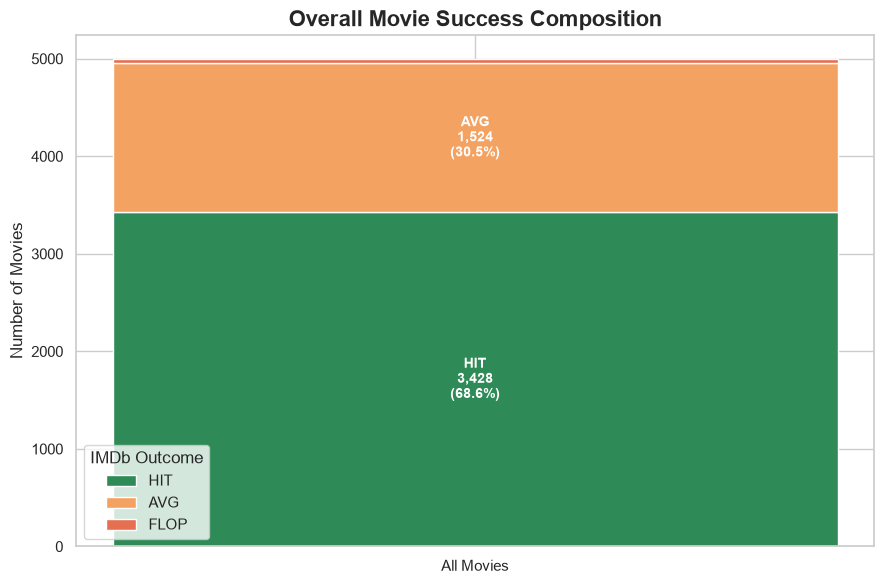

In [7]:
# SUCCESS DISTRIBUTION — STACKED BAR
fig, ax = plt.subplots(figsize=(9, 6))
bottom = 0
for category in SUCCESS_CATEGORIES:
    value = success.loc[success["IMDb category"] == category, "movies"].iloc[0]

    ax.bar(
        "All Movies",
        value,
        bottom=bottom,
        color=SUCCESS_COLORS[category],
        label=category,
        edgecolor="white",
        linewidth=1,
    )

    if value / len(df) * 100 >= 3:
        ax.text(
            0,
            bottom + value / 2,
            f"{category}\n{value:,}\n({value / len(df) * 100:.1f}%)",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white",
        )

    bottom += value
ax.set_title("Overall Movie Success Composition", fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Movies")
ax.legend(title="IMDb Outcome")
plt.tight_layout()
plt.show()

In [8]:
# GENERIC CATEGORICAL EDA

print_section("GENERIC CATEGORICAL EDA")

# Columns that should not be treated as useful business dimensions.
categorical_skip = {
    TARGET,
    "movie_title",
    "movie_imdb_link",
    "imdb_title_id",
}

categorical_columns = [
    c for c in df.select_dtypes(include=["object", "string", "category"]).columns
    if c not in categorical_skip
]

print("\nCategorical columns available for analysis:")
print(categorical_columns)

MAX_CATEGORIES = 15
MIN_MOVIES = 10

for column in categorical_columns:

    
    print(f"CATEGORICAL ANALYSIS: {column}")
    

    temp = df[[column, TARGET]].copy()
    temp[column] = temp[column].fillna("Unknown").astype(str).str.strip()

    # Handle pipe-separated dimensions such as genres/country/language.
    if temp[column].str.contains("|", regex=False).any():
        temp[column] = temp[column].str.split("|")
        temp = temp.explode(column)
        temp[column] = temp[column].str.strip()

    temp = temp[temp[column].ne("")]
    temp[column] = temp[column].replace("nan", "Unknown")

    # Keep categories with enough observations.
    category_counts = temp[column].value_counts()
    selected_categories = category_counts[
        category_counts >= MIN_MOVIES
        ].head(MAX_CATEGORIES).index

    temp = temp[temp[column].isin(selected_categories)]

    if temp.empty:
        print(f"Skipping {column}: insufficient observations.")
        continue



GENERIC CATEGORICAL EDA

Categorical columns available for analysis:
['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'actor_3_name', 'plot_keywords', 'language', 'country', 'content_rating']
CATEGORICAL ANALYSIS: color
CATEGORICAL ANALYSIS: director_name
CATEGORICAL ANALYSIS: actor_2_name
CATEGORICAL ANALYSIS: genres
CATEGORICAL ANALYSIS: actor_1_name
CATEGORICAL ANALYSIS: actor_3_name
CATEGORICAL ANALYSIS: plot_keywords
CATEGORICAL ANALYSIS: language
CATEGORICAL ANALYSIS: country
CATEGORICAL ANALYSIS: content_rating


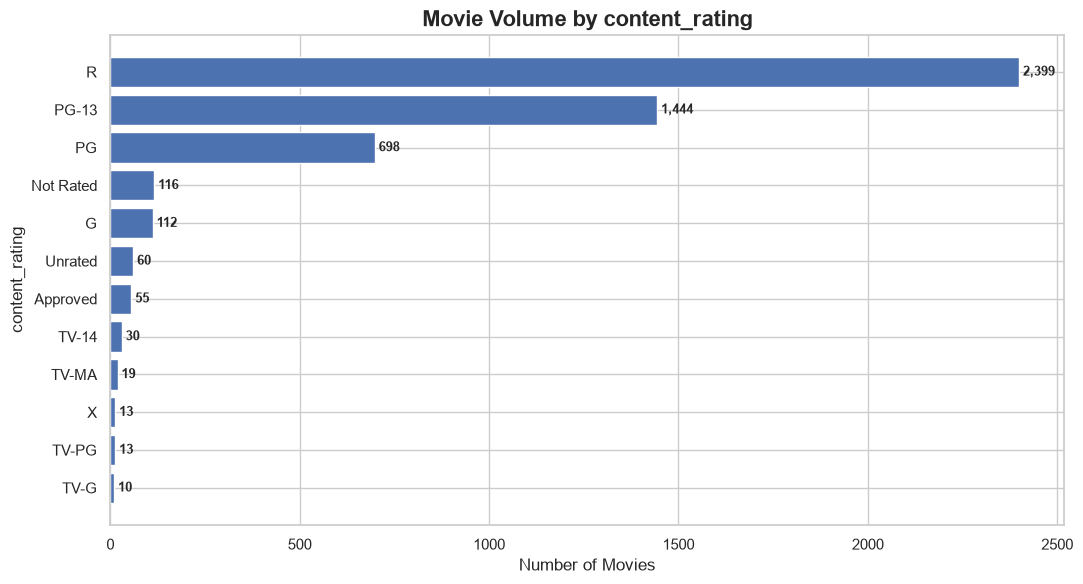

In [9]:
# MOVIE VOLUME BY CATEGORY
volume = (
        temp[column]
        .value_counts()
        .sort_values()
        .tail(MAX_CATEGORIES)
    )

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
        volume.index,
        volume.values,
        edgecolor="white",
    )

ax.set_title(
        f"Movie Volume by {column}",
        fontsize=16,
        fontweight="bold",
    )
ax.set_xlabel("Number of Movies")
ax.set_ylabel(column)

for bar, value in zip(bars, volume.values):
        ax.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f" {int(value):,}",
            va="center",
            fontsize=9,
            fontweight="bold",
            )

plt.tight_layout()
plt.show()

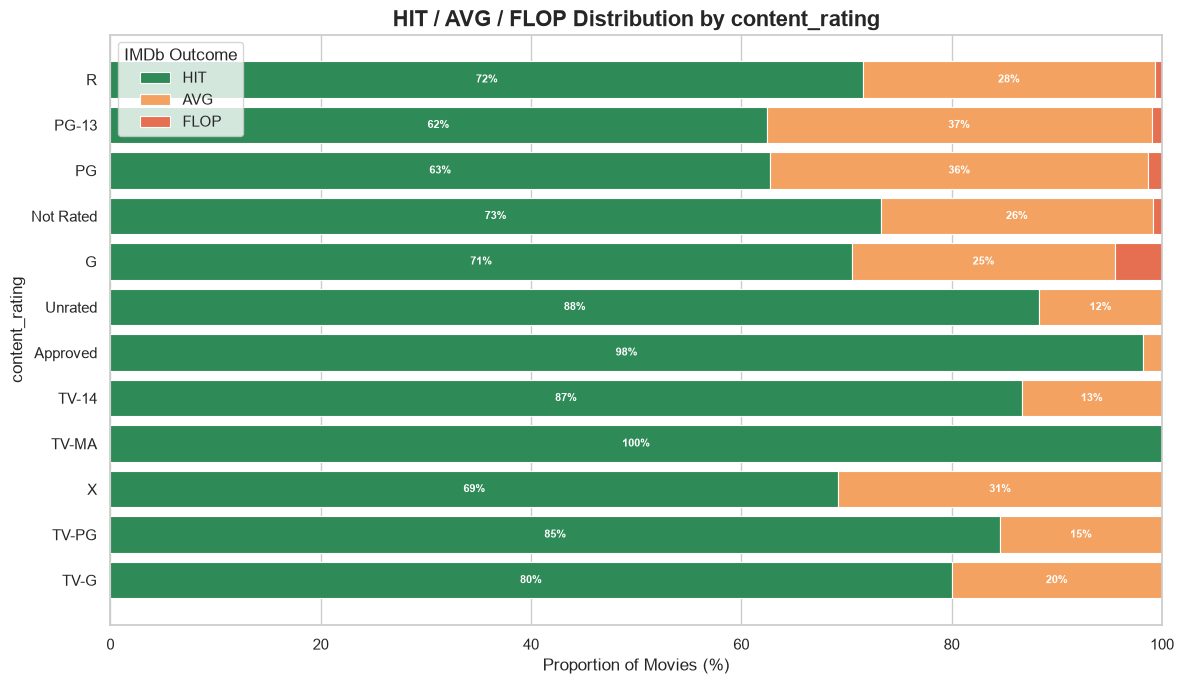

In [10]:
#  HIT / AVG / FLOP DISTRIBUTION
composition = (
        pd.crosstab(
            temp[column],
            temp[TARGET],
            normalize="index",
        )
        .mul(100)
        .reindex(columns=SUCCESS_CATEGORIES, fill_value=0)
    )

composition = composition.loc[
        volume.index.intersection(composition.index)
    ]

fig, ax = plt.subplots(figsize=(12, 7))

bottom = np.zeros(len(composition))

for category in SUCCESS_CATEGORIES:

        values = composition[category].values

        ax.barh(
            composition.index,
            values,
            left=bottom,
            color=SUCCESS_COLORS[category],
            label=category,
            edgecolor="white",
            linewidth=0.8,
        )

        for i, value in enumerate(values):
            if value >= 5:
                ax.text(
                    bottom[i] + value / 2,
                    i,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    fontweight="bold",
                    color="white",
                    )

        bottom += values

ax.set_xlim(0, 100)
ax.set_xlabel("Proportion of Movies (%)")
ax.set_ylabel(column)

ax.set_title(
        f"HIT / AVG / FLOP Distribution by {column}",
        fontsize=16,
        fontweight="bold",
    )

ax.legend(title="IMDb Outcome")

plt.tight_layout()
plt.show()

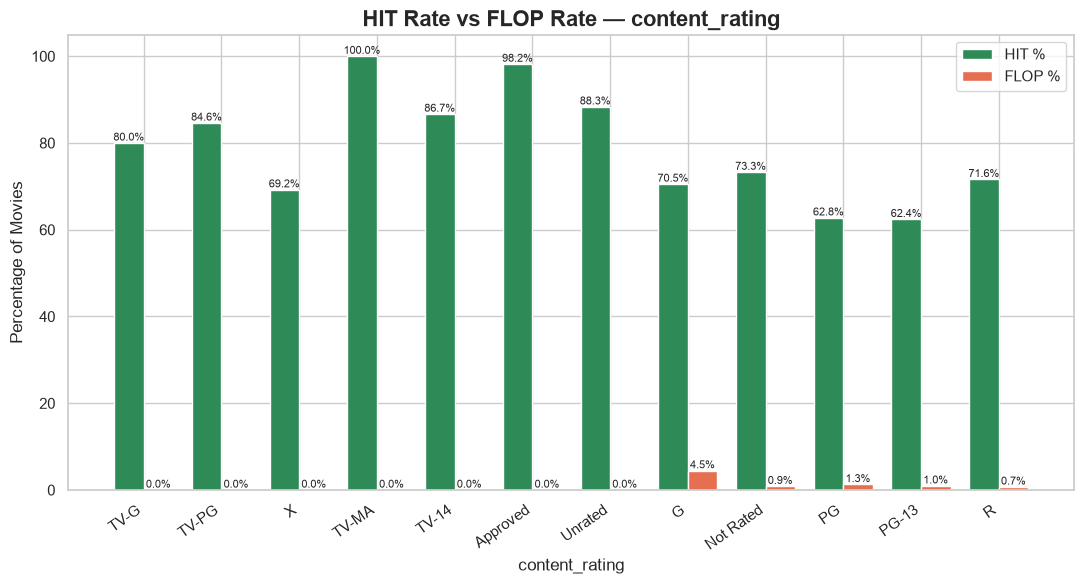

In [11]:
# HIT RATE VS FLOP RATE
success_rate = composition.copy()

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(success_rate))
width = 0.38

hit_bars = ax.bar(
        x - width / 2,
        success_rate["HIT"],
        width,
        label="HIT %",
        color=SUCCESS_COLORS["HIT"],
        )

flop_bars = ax.bar(
        x + width / 2,
        success_rate["FLOP"],
        width,
        label="FLOP %",
        color=SUCCESS_COLORS["FLOP"],
        )

ax.set_xticks(x)
ax.set_xticklabels(success_rate.index, rotation=35, ha="right")
ax.set_ylabel("Percentage of Movies")
ax.set_xlabel(column)

ax.set_title(
        f"HIT Rate vs FLOP Rate — {column}",
        fontsize=16,
        fontweight="bold",
    )

ax.legend()

for bars in [hit_bars, flop_bars]:
        for bar in bars:
            value = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                )

plt.tight_layout()
plt.show()

In [12]:
# CATEGORY SUMMARY TABLE

category_summary = (
        temp.groupby(column)
        .agg(
            movies=(TARGET, "size"),
            hit_rate=(TARGET, lambda x: (x == "HIT").mean()),
            avg_rate=(TARGET, lambda x: (x == "AVG").mean()),
            flop_rate=(TARGET, lambda x: (x == "FLOP").mean()),
        )
        .query("movies >= @MIN_MOVIES")
        .sort_values("hit_rate", ascending=False)
        .head(MAX_CATEGORIES)
        .reset_index()
    )

if "roi" in df.columns:
        # Rebuild numeric values at category level.
        numeric_temp = df[[column, "roi"]].copy()
        numeric_temp[column] = numeric_temp[column].fillna("Unknown").astype(str)

        if numeric_temp[column].str.contains("|", regex=False).any():
            numeric_temp[column] = numeric_temp[column].str.split("|")
            numeric_temp = numeric_temp.explode(column)

        numeric_temp["roi"] = pd.to_numeric(
            numeric_temp["roi"],
            errors="coerce",
        )

        roi_summary = (
            numeric_temp.groupby(column)["roi"]
            .median()
            .rename("median_roi")
        )

        category_summary = category_summary.merge(
            roi_summary,
            left_on=column,
            right_index=True,
            how="left",
        )

category_display = category_summary.copy()

category_display["hit_rate"] = category_display["hit_rate"].map(
        lambda x: f"{x:.1%}"
    )
category_display["avg_rate"] = category_display["avg_rate"].map(
        lambda x: f"{x:.1%}"
    )
category_display["flop_rate"] = category_display["flop_rate"].map(
        lambda x: f"{x:.1%}"
    )

if "median_roi" in category_display.columns:
        category_display["median_roi"] = category_display["median_roi"].map(
            lambda x: f"{x:.2f}" if pd.notna(x) else "N/A"
        )

print("\nCategory performance summary:")
print(category_display.to_string(index=False))


Category performance summary:
content_rating  movies hit_rate avg_rate flop_rate median_roi
         TV-MA      19   100.0%     0.0%      0.0%       0.27
      Approved      55    98.2%     1.8%      0.0%       7.48
       Unrated      60    88.3%    11.7%      0.0%       2.21
         TV-14      30    86.7%    13.3%      0.0%       0.27
         TV-PG      13    84.6%    15.4%      0.0%       0.27
          TV-G      10    80.0%    20.0%      0.0%       1.45
     Not Rated     116    73.3%    25.9%      0.9%       0.27
             R    2399    71.6%    27.7%      0.7%       0.25
             G     112    70.5%    25.0%      4.5%       0.37
             X      13    69.2%    30.8%      0.0%       4.65
            PG     698    62.8%    36.0%      1.3%       0.37
         PG-13    1444    62.4%    36.6%      1.0%       0.10


In [13]:
# GENERIC NUMERICAL EDA

print_section("GENERIC NUMERICAL EDA")

numeric_columns = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in {"is_color"}
]
for column in numeric_columns:
    print(f"NUMERICAL ANALYSIS: {column}")
    

    numeric = pd.to_numeric(df[column], errors="coerce")

    if numeric.dropna().empty:
        print(f"Skipping {column}: no valid numeric observations.")
        continue



GENERIC NUMERICAL EDA
NUMERICAL ANALYSIS: num_critic_for_reviews
NUMERICAL ANALYSIS: duration
NUMERICAL ANALYSIS: director_facebook_likes
NUMERICAL ANALYSIS: actor_3_facebook_likes
NUMERICAL ANALYSIS: actor_1_facebook_likes
NUMERICAL ANALYSIS: gross
NUMERICAL ANALYSIS: num_voted_users
NUMERICAL ANALYSIS: cast_total_facebook_likes
NUMERICAL ANALYSIS: facenumber_in_poster
NUMERICAL ANALYSIS: num_user_for_reviews
NUMERICAL ANALYSIS: budget
NUMERICAL ANALYSIS: title_year
NUMERICAL ANALYSIS: actor_2_facebook_likes
NUMERICAL ANALYSIS: aspect_ratio
NUMERICAL ANALYSIS: movie_facebook_likes
NUMERICAL ANALYSIS: log_budget
NUMERICAL ANALYSIS: log_gross
NUMERICAL ANALYSIS: roi
NUMERICAL ANALYSIS: review_ratio
NUMERICAL ANALYSIS: votes_per_review
NUMERICAL ANALYSIS: actor_lead_share
NUMERICAL ANALYSIS: director_share
NUMERICAL ANALYSIS: movie_age


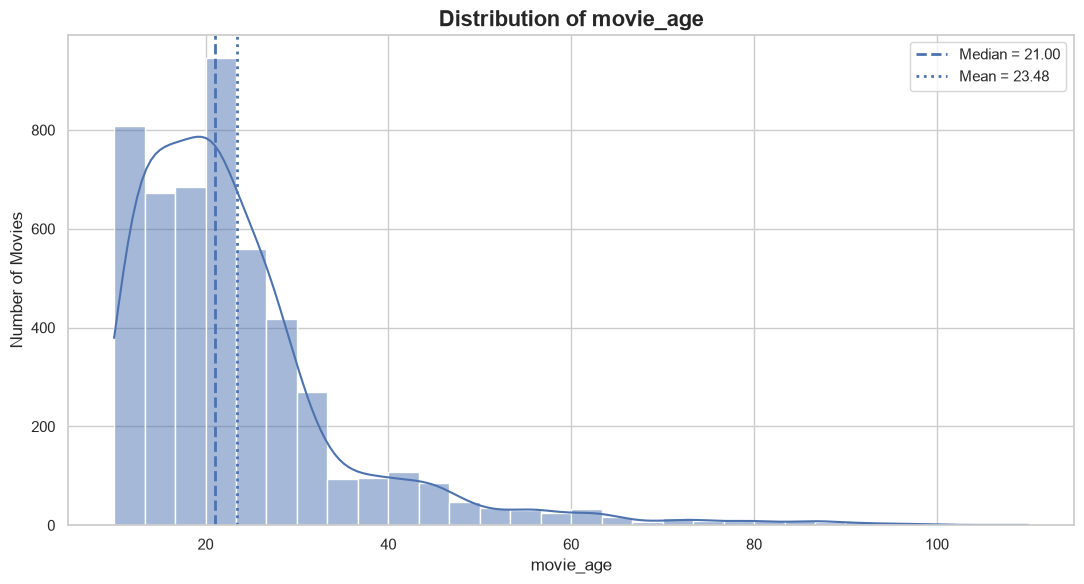

In [14]:
# DISTRIBUTION
fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
        numeric.dropna(),
        kde=True,
        bins=30,
        ax=ax,
    )

ax.axvline(
        numeric.median(),
        linestyle="--",
        linewidth=2,
        label=f"Median = {numeric.median():,.2f}",
    )

ax.axvline(
        numeric.mean(),
        linestyle=":",
        linewidth=2,
        label=f"Mean = {numeric.mean():,.2f}",
    )

ax.set_title(
        f"Distribution of {column}",
        fontsize=16,
        fontweight="bold",
    )

ax.set_xlabel(column)
ax.set_ylabel("Number of Movies")
ax.legend()

plt.tight_layout()
plt.show()

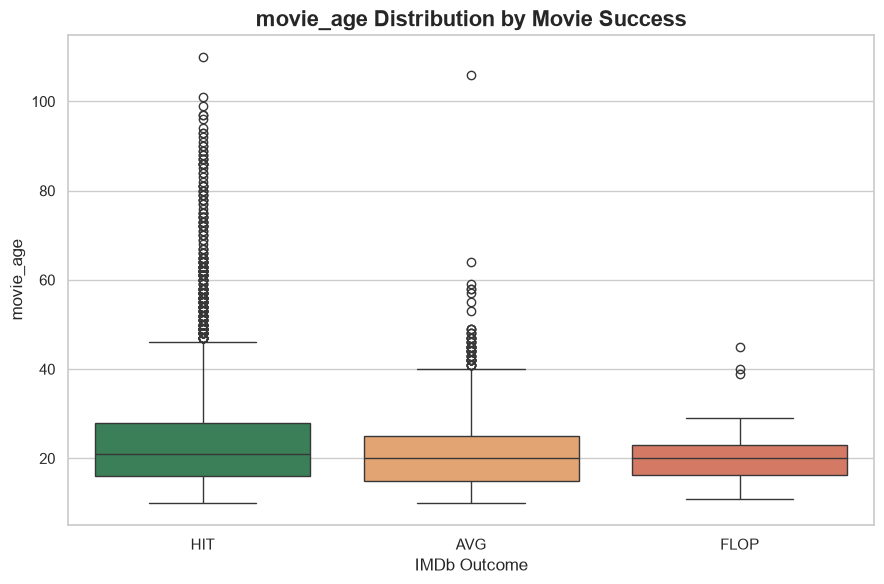

In [15]:
# DISTRIBUTION BY HIT / AVG / FLOP
box_data = df[[TARGET, column]].copy()
box_data[column] = pd.to_numeric(
        box_data[column],
        errors="coerce",
    )
box_data = box_data.dropna(subset=[column, TARGET])

fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
        data=box_data,
        x=TARGET,
        y=column,
        order=SUCCESS_CATEGORIES,
        palette=SUCCESS_COLORS,
        ax=ax,
    )

ax.set_title(
        f"{column} Distribution by Movie Success",
        fontsize=16,
        fontweight="bold",
    )

ax.set_xlabel("IMDb Outcome")
ax.set_ylabel(column)

plt.tight_layout()
plt.show()


Numerical summary by success category:
             count   mean  median    std  min  max
imdb_binned                                       
HIT           3428  24.62    21.0  13.59   10  110
AVG           1524  20.99    20.0   8.58   10  106
FLOP            46  20.87    20.0   7.23   11   45


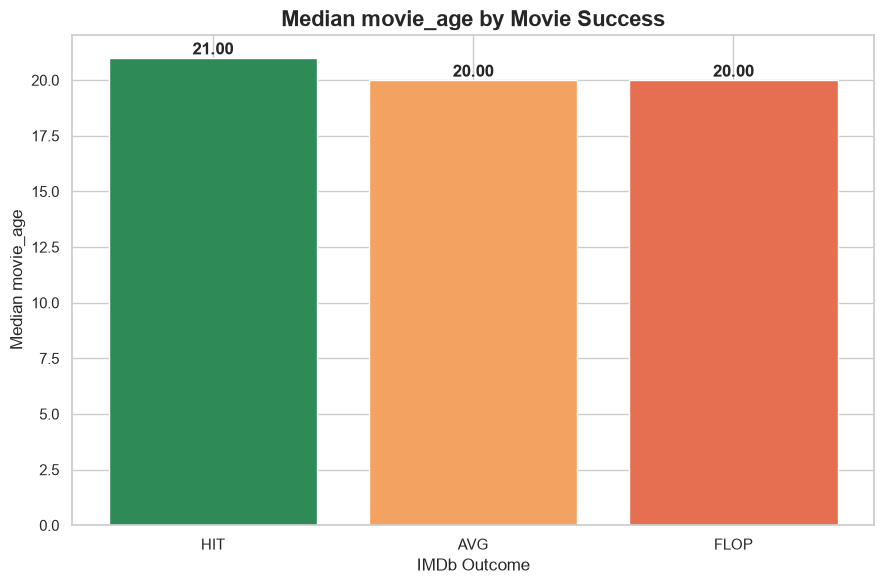

In [17]:
# MEDIAN / MEAN BY SUCCESS CATEGORY
numerical_success = (
        df.groupby(TARGET)[column]
        .agg(
            count="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max",
        )
        .reindex(SUCCESS_CATEGORIES)
    )

print("\nNumerical summary by success category:")
print(numerical_success.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
        SUCCESS_CATEGORIES,
        numerical_success["median"],
        color=[SUCCESS_COLORS[x] for x in SUCCESS_CATEGORIES],
        edgecolor="white",
    )

ax.set_title(
        f"Median {column} by Movie Success",
        fontsize=16,
        fontweight="bold",
    )

ax.set_xlabel("IMDb Outcome")
ax.set_ylabel(f"Median {column}")

for bar, value in zip(bars, numerical_success["median"]):
        if pd.notna(value):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:,.2f}",
                ha="center",
                va="bottom",
                fontweight="bold",
                )

plt.tight_layout()
plt.show()

In [18]:
# OUTLIER ANALYSIS
q1 = numeric.quantile(0.25)
q3 = numeric.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_count = (
            (numeric < lower_bound) |
            (numeric > upper_bound)
    ).sum()

outlier_rate = (
        outlier_count / numeric.notna().sum()
        if numeric.notna().sum() > 0
        else np.nan
    )

print(
        f"Median       : {numeric.median():,.2f}\n"
        f"Mean         : {numeric.mean():,.2f}\n"
        f"Std Dev      : {numeric.std():,.2f}\n"
        f"P25          : {q1:,.2f}\n"
        f"P75          : {q3:,.2f}\n"
        f"IQR          : {iqr:,.2f}\n"
        f"Min          : {numeric.min():,.2f}\n"
        f"Max          : {numeric.max():,.2f}\n"
        f"Missing      : {numeric.isna().sum():,}\n"
        f"Outliers     : {outlier_count:,}\n"
        f"Outlier Rate : {outlier_rate:.1%}"
    )

Median       : 21.00
Mean         : 23.48
Std Dev      : 12.35
P25          : 15.00
P75          : 27.00
IQR          : 12.00
Min          : 10.00
Max          : 110.00
Missing      : 0
Outliers     : 282
Outlier Rate : 5.6%




SUCCESS RATE BY RELEASE YEAR


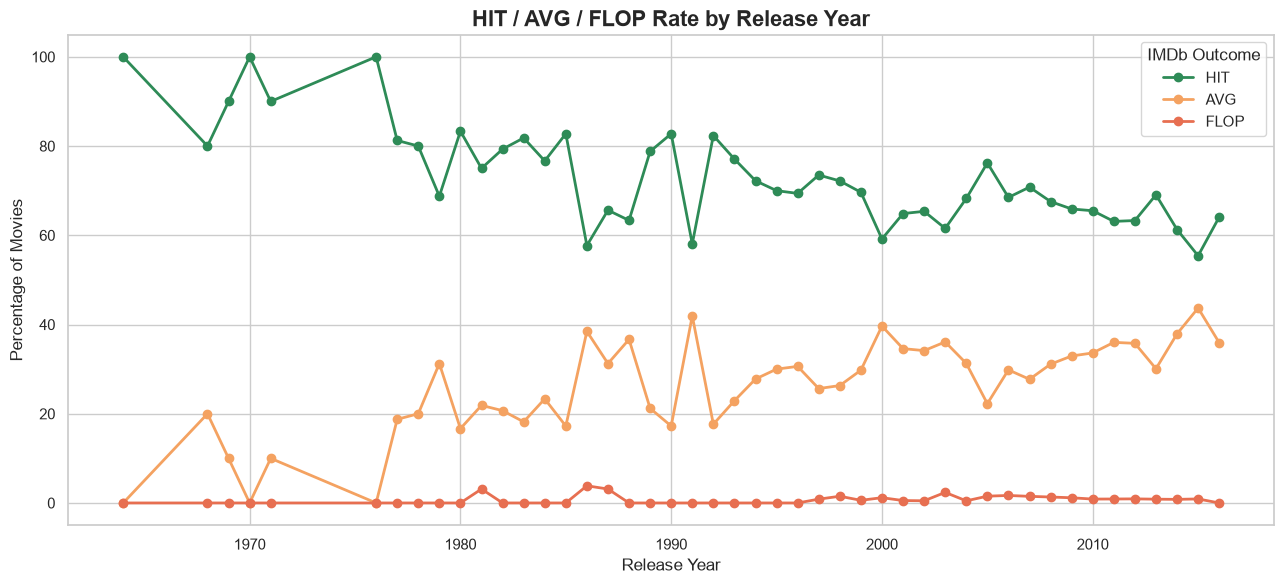

In [19]:
#  SUCCESS RATE BY RELEASE YEAR

print_section("SUCCESS RATE BY RELEASE YEAR")

if "title_year" in df.columns:

    yearly_success = (
        pd.crosstab(
            df["title_year"],
            df[TARGET],
            normalize="index",
        )
        .mul(100)
        .reindex(columns=SUCCESS_CATEGORIES, fill_value=0)
    )

    yearly_success = yearly_success.loc[
        df["title_year"].value_counts().loc[
            lambda x: x >= 10
        ].index.intersection(yearly_success.index)
    ].sort_index()

    fig, ax = plt.subplots(figsize=(13, 6))

    for category in SUCCESS_CATEGORIES:
        ax.plot(
            yearly_success.index,
            yearly_success[category],
            marker="o",
            linewidth=2,
            label=category,
            color=SUCCESS_COLORS[category],
        )

    ax.set_title(
        "HIT / AVG / FLOP Rate by Release Year",
        fontsize=16,
        fontweight="bold",
    )

    ax.set_xlabel("Release Year")
    ax.set_ylabel("Percentage of Movies")
    ax.legend(title="IMDb Outcome")

    plt.tight_layout()
    plt.show()

In [20]:
# BUSINESS-READY EDA SUMMARY

print_section("EDA SUMMARY")

print(
    """
Recommended PPT storyline:

1. Overall HIT / AVG / FLOP portfolio composition
2. Success distribution by genre
3. Success distribution by country
4. Success distribution by content rating
5. Success distribution by language
6. Success distribution by other important categorical dimensions
7. Numerical distributions
8. Numerical comparison across HIT / AVG / FLOP
9. Outlier analysis
10. Correlation between financial / audience variables
11. Success-rate trend over release years
12. Identify dimensions with unusually high HIT or FLOP concentration

Important interpretation rule:
Categorical HIT / AVG / FLOP percentages show association and composition.
They should not automatically be interpreted as causal drivers.
"""
)

print("\nGeneric EDA analysis completed successfully.")




EDA SUMMARY

Recommended PPT storyline:

1. Overall HIT / AVG / FLOP portfolio composition
2. Success distribution by genre
3. Success distribution by country
4. Success distribution by content rating
5. Success distribution by language
6. Success distribution by other important categorical dimensions
7. Numerical distributions
8. Numerical comparison across HIT / AVG / FLOP
9. Outlier analysis
10. Correlation between financial / audience variables
11. Success-rate trend over release years
12. Identify dimensions with unusually high HIT or FLOP concentration

Important interpretation rule:
Categorical HIT / AVG / FLOP percentages show association and composition.
They should not automatically be interpreted as causal drivers.


Generic EDA analysis completed successfully.


In [21]:
#  BUDGET ANALYSIS


print_section("PRODUCTION DECISIONS: BUDGET")

df["budget_band"] = pd.cut(
    df["budget"],
    [-np.inf, 5e6, 15e6, 40e6, 100e6, np.inf],
    labels=[
        "Micro\n(<5m)",
        "Low\n(5m-15m)",
        "Mid\n(15m-40m)",
        "Upper-mid\n(40m-100m)",
        "Tentpole\n(100m+)",
    ],
)

budget_summary = (
    df.groupby("budget_band", observed=True)
    .agg(
        movies=("gross", "size"),
        median_budget=("budget", "median"),
        median_gross=("gross", "median"),
        median_roi=("roi", "median"),
        profitable_share=("roi", lambda x: (x > 0).mean()),
    )
    .reset_index()
)

print("\nBudget summary:")

budget_display = budget_summary.copy()

budget_display["median_budget"] = budget_display["median_budget"].map(
    lambda x: f"{x:,.0f}"
)

budget_display["median_gross"] = budget_display["median_gross"].map(
    lambda x: f"{x:,.0f}"
)

budget_display["median_roi"] = budget_display["median_roi"].map(lambda x: f"{x:.2f}")

budget_display["profitable_share"] = budget_display["profitable_share"].map(
    lambda x: f"{x:.1%}"
)

print(budget_display.to_string(index=False))




PRODUCTION DECISIONS: BUDGET

Budget summary:
          budget_band  movies median_budget median_gross median_roi profitable_share
         Micro\n(<5m)    1077     1,900,000   19,472,057       5.36            73.4%
        Low\n(5m-15m)     938    10,000,000   18,312,450       0.76            62.3%
       Mid\n(15m-40m)    1817    22,000,000   25,445,749       0.11            53.8%
Upper-mid\n(40m-100m)     848    60,000,000   58,379,608      -0.06            47.1%
    Tentpole\n(100m+)     318   150,000,000  140,847,436       0.01            50.3%


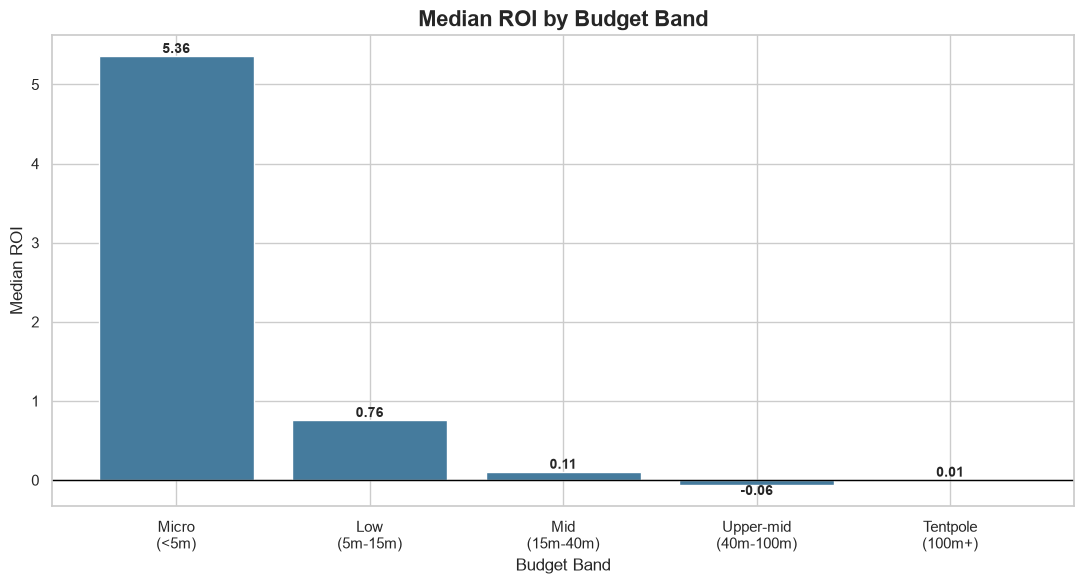

In [22]:
# 2A. ROI BY BUDGET
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(budget_summary))

bars = ax.bar(x, budget_summary["median_roi"], color="#457B9D", edgecolor="white")

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(x)

ax.set_xticklabels(budget_summary["budget_band"])

ax.set_ylabel("Median ROI")

ax.set_xlabel("Budget Band")

ax.set_title("Median ROI by Budget Band", fontsize=16, fontweight="bold")

for bar, value in zip(bars, budget_summary["median_roi"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


Budget success composition:
          budget_band       HIT       AVG     FLOP
         Micro\n(<5m) 69.545032 29.433612 1.021356
        Low\n(5m-15m) 70.362473 28.678038 0.959488
       Mid\n(15m-40m) 66.923500 32.030820 1.045680
Upper-mid\n(40m-100m) 65.212264 33.962264 0.825472
    Tentpole\n(100m+) 78.616352 21.383648 0.000000


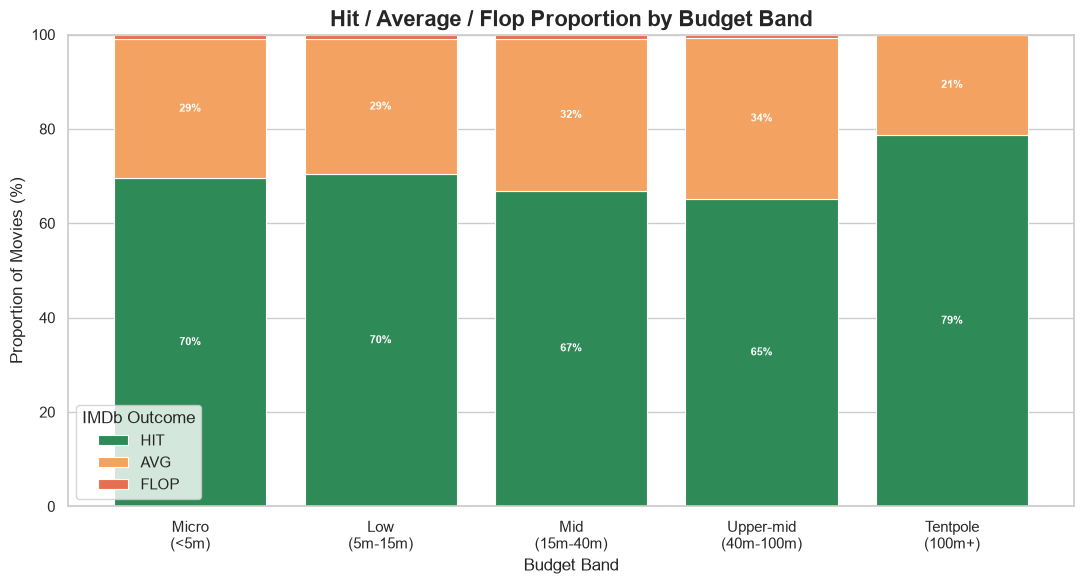

In [23]:
# BUDGET — 100% STACKED BAR

budget_category = (
    pd.crosstab(df["budget_band"], df[TARGET], normalize="index")
    .mul(100)
    .reindex(columns=SUCCESS_CATEGORIES, fill_value=0)
    .reset_index()
)

print("\nBudget success composition:")

print(budget_category.to_string(index=False))

create_100_percent_stacked_bar(
    budget_category,
    "budget_band",
    "Hit / Average / Flop Proportion by Budget Band",
    "Budget Band",
)

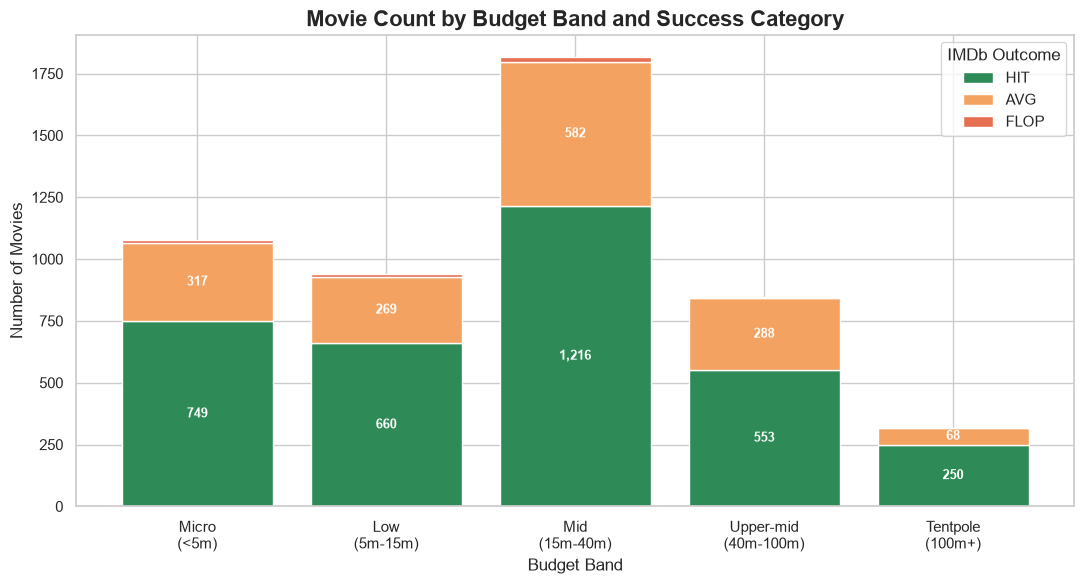

In [24]:
#  BUDGET NUMBER OF MOVIES STACKED
# ============================================================

budget_counts = (
    pd.crosstab(df["budget_band"], df[TARGET])
    .reindex(columns=SUCCESS_CATEGORIES, fill_value=0)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(budget_counts))

bottom = np.zeros(len(budget_counts))

for category in SUCCESS_CATEGORIES:
    values = budget_counts[category].values

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        color=SUCCESS_COLORS[category],
        label=category,
        edgecolor="white",
    )

    # Number inside each segment
    for i, value in enumerate(values):
        if value >= 20:
            ax.text(
                i,
                bottom[i] + value / 2,
                f"{int(value):,}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white",
            )

    bottom += values

ax.set_xticks(x)

ax.set_xticklabels(budget_counts["budget_band"])

ax.set_ylabel("Number of Movies")

ax.set_xlabel("Budget Band")

ax.set_title(
    "Movie Count by Budget Band and Success Category", fontsize=16, fontweight="bold"
)

ax.legend(title="IMDb Outcome")

plt.tight_layout()
plt.show()

In [25]:
# GENRE ANALYSIS

print_section("TOP GENRES BY ROI")

genre_data = df.assign(genre=(df["genres"].fillna("Unknown").str.split("|"))).explode(
    "genre"
)
genre_summary = (
    genre_data.groupby("genre")
    .agg(
        movies=("gross", "size"),
        median_roi=("roi", "median"),
        profitable_share=("roi", lambda x: (x > 0).mean()),
    )
    .query("movies >= 30")
    .sort_values("median_roi", ascending=False)
)

top_genres = genre_summary.head(10).sort_values("median_roi").reset_index()

print("\nTop 10 genres by ROI:")

genre_display = top_genres.copy()

genre_display["median_roi"] = genre_display["median_roi"].map(lambda x: f"{x:.2f}")

genre_display["profitable_share"] = genre_display["profitable_share"].map(
    lambda x: f"{x:.1%}"
)
print(genre_display.to_string(index=False))



TOP GENRES BY ROI

Top 10 genres by ROI:
      genre  movies median_roi profitable_share
     Comedy    1862       0.27            59.4%
    Romance    1098       0.27            57.7%
    Mystery     493       0.27            60.0%
  Animation     242       0.27            62.4%
    Musical     132       0.27            57.6%
      Music     212       0.27            59.0%
Documentary     121       0.27            54.5%
    Western      94       0.27            58.5%
     Family     544       0.34            65.8%
     Horror     556       0.80            72.1%


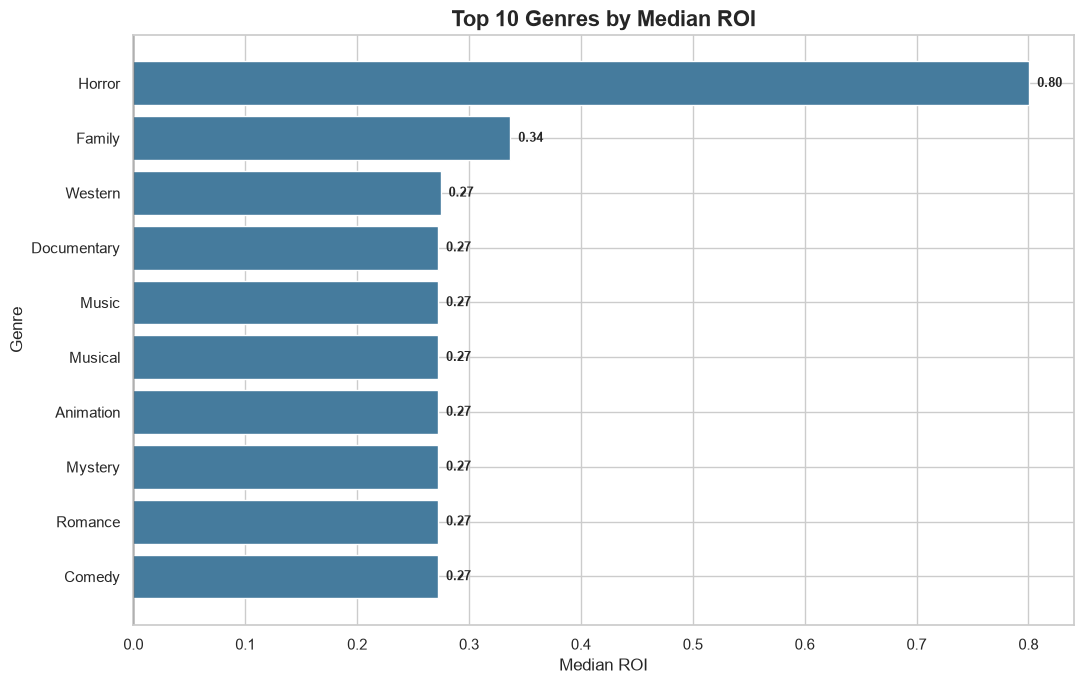

In [26]:
# TOP GENRES — ROI

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(top_genres["genre"], top_genres["median_roi"], color="#457B9D")

ax.axvline(0, color="black", linewidth=1)

for bar, value in zip(bars, top_genres["median_roi"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.2f}",
        ha="left" if value >= 0 else "right",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title("Top 10 Genres by Median ROI", fontsize=16, fontweight="bold")

ax.set_xlabel("Median ROI")

ax.set_ylabel("Genre")

plt.tight_layout()
plt.show()


Genre success composition:
      genre       HIT       AVG     FLOP
     Comedy 60.418904 38.399570 1.181525
    Romance 70.856102 28.506375 0.637523
    Mystery 68.965517 30.831643 0.202840
  Animation 71.900826 26.859504 1.239669
    Musical 72.727273 25.000000 2.272727
      Music 70.283019 28.301887 1.415094
Documentary 89.256198  9.090909 1.652893
    Western 74.468085 25.531915 0.000000
     Family 60.477941 38.051471 1.470588
     Horror 44.604317 54.136691 1.258993


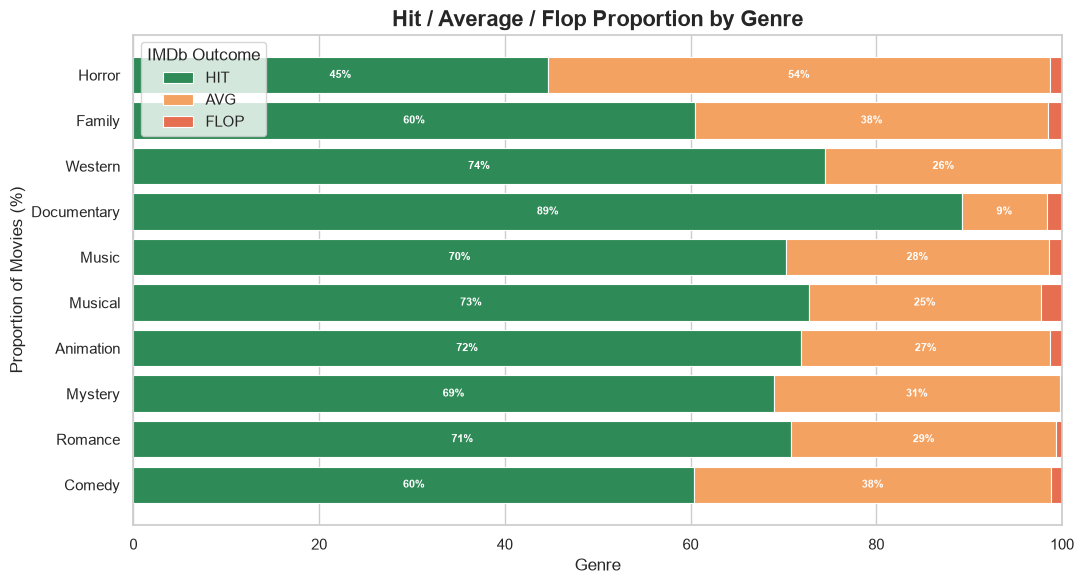

In [27]:
# GENRE — 100% STACKED BAR

top_genre_names = top_genres["genre"].tolist()

genre_category = (
    pd.crosstab(genre_data["genre"], genre_data[TARGET], normalize="index")
    .mul(100)
    .reindex(index=top_genre_names, columns=SUCCESS_CATEGORIES, fill_value=0)
    .reset_index()
)

print("\nGenre success composition:")

print(genre_category.to_string(index=False))

create_100_percent_stacked_bar(
    genre_category,
    "genre",
    "Hit / Average / Flop Proportion by Genre",
    "Genre",
    horizontal=True,
)

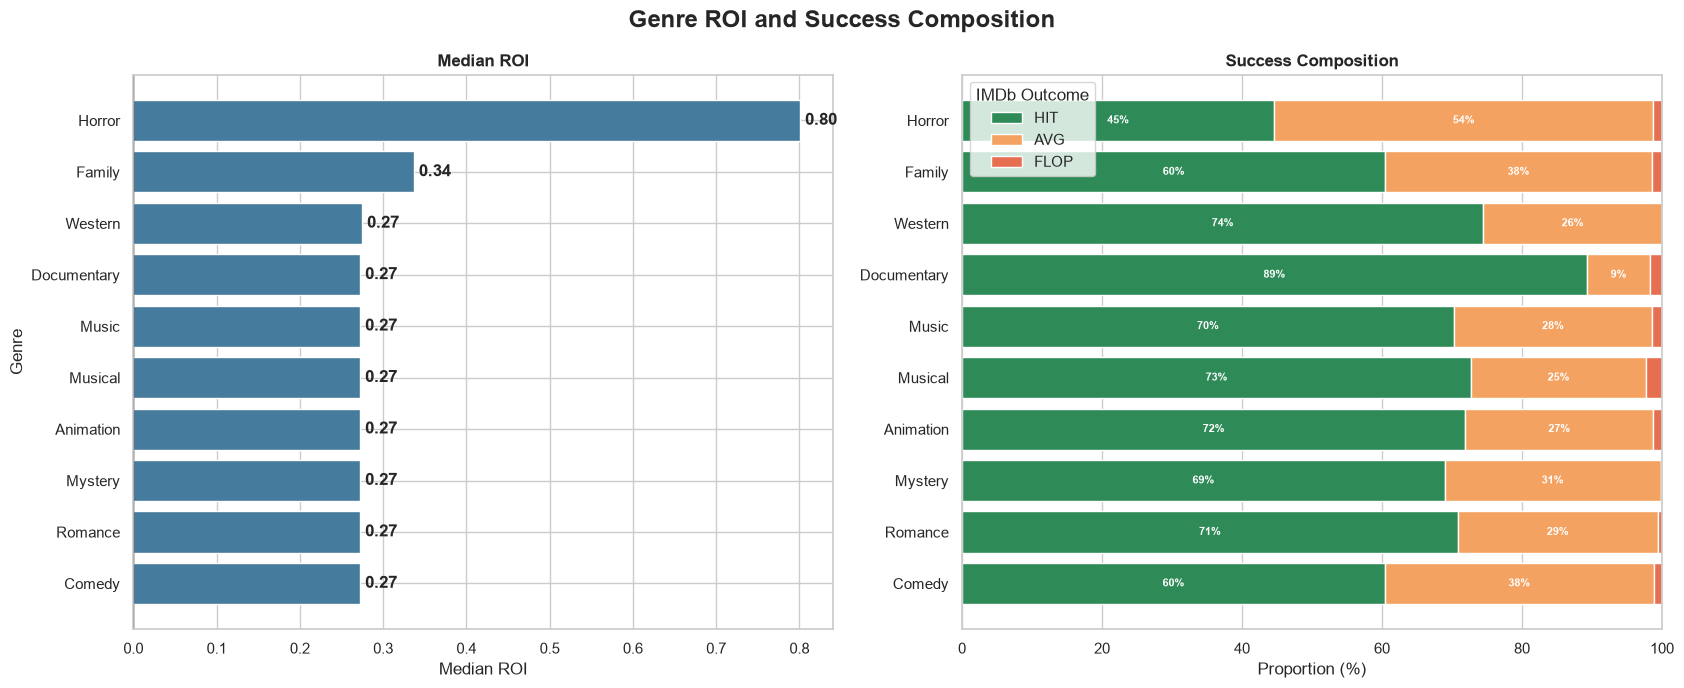



MARKETING ATTENTION EFFECTIVENESS

movie_facebook_likes is used as a campaign-attention proxy.
This analysis shows association, not causal marketing impact.


In [28]:
# GENRE — ROI + SUCCESS COMPOSITION

genre_combined = top_genres.merge(genre_category, on="genre", how="left")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ROI chart
axes[0].barh(genre_combined["genre"], genre_combined["median_roi"], color="#457B9D")

axes[0].axvline(0, color="black", linewidth=1)

for i, value in enumerate(genre_combined["median_roi"]):
    axes[0].text(
        value,
        i,
        f" {value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontweight="bold",
    )

axes[0].set_title("Median ROI", fontweight="bold")

axes[0].set_xlabel("Median ROI")

axes[0].set_ylabel("Genre")

# Stacked chart
bottom = np.zeros(len(genre_combined))

for category in SUCCESS_CATEGORIES:
    values = genre_combined[category].values

    axes[1].barh(
        genre_combined["genre"],
        values,
        left=bottom,
        color=SUCCESS_COLORS[category],
        label=category,
        edgecolor="white",
    )

    for i, value in enumerate(values):
        if value >= 5:
            axes[1].text(
                bottom[i] + value / 2,
                i,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
                fontweight="bold",
            )

    bottom += values

axes[1].set_xlim(0, 100)
axes[1].set_title("Success Composition", fontweight="bold")
axes[1].set_xlabel("Proportion (%)")
axes[1].set_ylabel("")
axes[1].legend(title="IMDb Outcome")
fig.suptitle("Genre ROI and Success Composition", fontsize=17, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. MARKETING ATTENTION

print_section("MARKETING ATTENTION EFFECTIVENESS")

print("\nmovie_facebook_likes is used as a campaign-attention proxy.")

print("This analysis shows association, not causal marketing impact.")

attention = df.dropna(subset=["movie_facebook_likes", "budget", "gross", "roi"]).copy()

attention["attention_tier"] = pd.qcut(
    attention["movie_facebook_likes"].rank(method="first"),
    q=4,
    labels=["Low", "Mid-low", "Mid-high", "High"],
)

attention["likes_per_budget_m"] = (
    attention["movie_facebook_likes"] / (attention["budget"] / 1_000_000)
).clip(lower=0.1)

In [29]:
# ATTENTION SUMMARY
attention_summary = (
    attention.groupby("attention_tier", observed=True)
    .agg(
        movies=("gross", "size"),
        median_likes=("movie_facebook_likes", "median"),
        likes_per_budget_m=("likes_per_budget_m", "median"),
        median_gross=("gross", "median"),
        median_roi=("roi", "median"),
        profitable_share=("roi", lambda x: (x > 0).mean()),
    )
    .reset_index()
)

print("\nAttention summary:")

attention_display = attention_summary.copy()
attention_display["median_likes"] = attention_display["median_likes"].map(
    lambda x: f"{x:,.0f}"
)
attention_display["likes_per_budget_m"] = attention_display["likes_per_budget_m"].map(
    lambda x: f"{x:,.1f}"
)
attention_display["median_gross"] = attention_display["median_gross"].map(
    lambda x: f"{x:,.0f}"
)
attention_display["median_roi"] = attention_display["median_roi"].map(
    lambda x: f"{x:.2f}"
)
attention_display["profitable_share"] = attention_display["profitable_share"].map(
    lambda x: f"{x:.1%}"
)
print(attention_display.to_string(index=False))


Attention summary:
attention_tier  movies median_likes likes_per_budget_m median_gross median_roi profitable_share
           Low    1250            0                0.1   41,832,513       0.15            56.2%
       Mid-low    1249            0                0.1   18,090,181       0.59            62.1%
      Mid-high    1249          593               44.4   19,281,235      -0.03            49.5%
          High    1250       19,000              692.0   42,919,096       0.34            65.2%


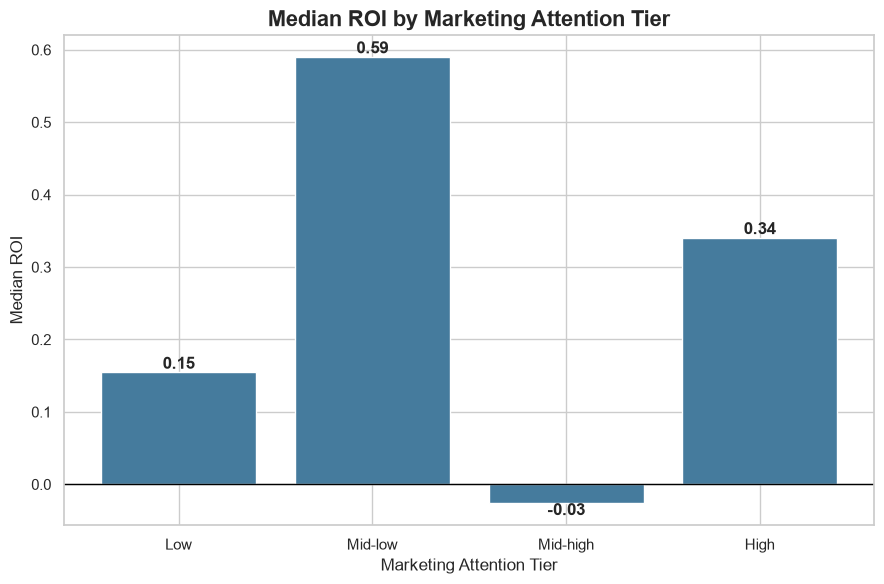

In [30]:
# ROI BY ATTENTION

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(attention_summary))
bars = ax.bar(x, attention_summary["median_roi"], color="#457B9D")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(attention_summary["attention_tier"])
ax.set_xlabel("Marketing Attention Tier")
ax.set_ylabel("Median ROI")
ax.set_title("Median ROI by Marketing Attention Tier", fontsize=16, fontweight="bold")
for bar, value in zip(bars, attention_summary["median_roi"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

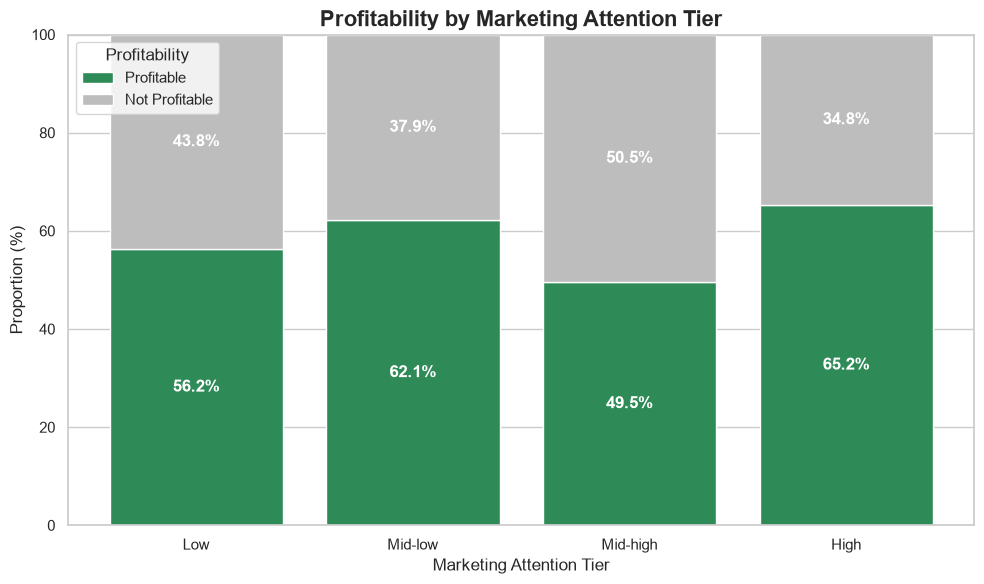

In [31]:
# PROFITABILITY — 100% STACKED

profitability_plot = attention_summary.copy()
profitability_plot["profitable"] = profitability_plot["profitable_share"] * 100
profitability_plot["not_profitable"] = 100 - profitability_plot["profitable"]
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(profitability_plot))
profitable = profitability_plot["profitable"].values
not_profitable = profitability_plot["not_profitable"].values
bars1 = ax.bar(x, profitable, color="#2E8B57", label="Profitable", edgecolor="white")
ax.bar(
    x,
    not_profitable,
    bottom=profitable,
    color="#BDBDBD",
    label="Not Profitable",
    edgecolor="white",
)

for i, value in enumerate(profitable):
    if value >= 5:
        ax.text(
            i,
            value / 2,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )

for i, value in enumerate(not_profitable):
    if value >= 5:
        ax.text(
            i,
            profitable[i] + value / 2,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )

ax.set_xticks(x)
ax.set_xticklabels(profitability_plot["attention_tier"])
ax.set_ylim(0, 100)
ax.set_xlabel("Marketing Attention Tier")
ax.set_ylabel("Proportion (%)")
ax.set_title(
    "Profitability by Marketing Attention Tier", fontsize=16, fontweight="bold"
)
ax.legend(title="Profitability")
plt.tight_layout()
plt.show()


Attention success composition:
attention_tier       HIT       AVG     FLOP
           Low 69.760000 29.440000 0.800000
       Mid-low 69.415532 29.543635 1.040833
      Mid-high 49.559648 48.678943 1.761409
          High 85.600000 14.320000 0.080000


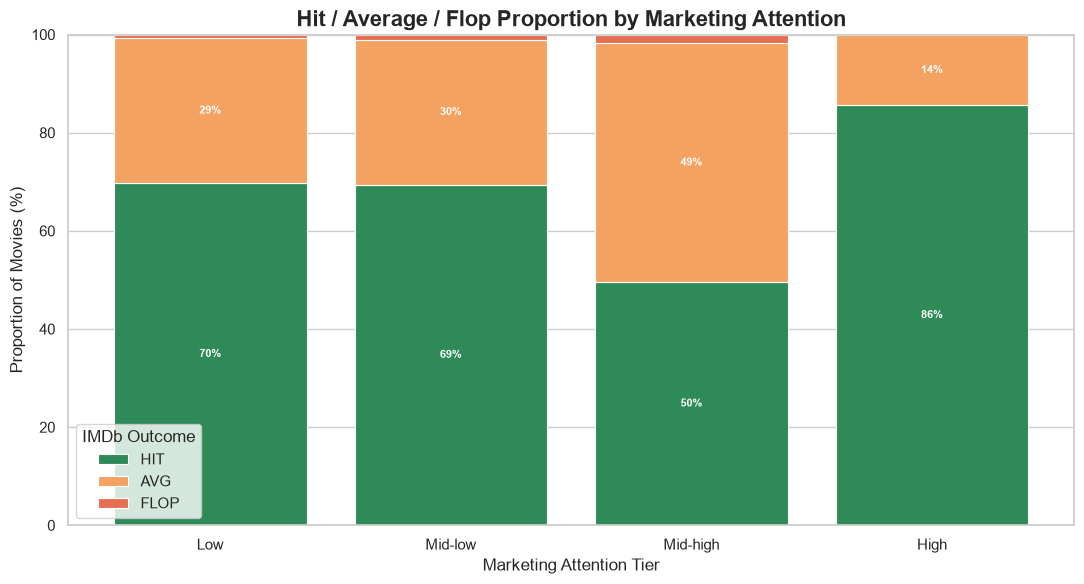

In [32]:
#  ATTENTION — HIT / AVG / FLOP STACKED

attention_category = (
    pd.crosstab(attention["attention_tier"], attention[TARGET], normalize="index")
    .mul(100)
    .reindex(columns=SUCCESS_CATEGORIES, fill_value=0)
    .reset_index()
)

print("\nAttention success composition:")

print(attention_category.to_string(index=False))

create_100_percent_stacked_bar(
    attention_category,
    "attention_tier",
    "Hit / Average / Flop Proportion by Marketing Attention",
    "Marketing Attention Tier",
)

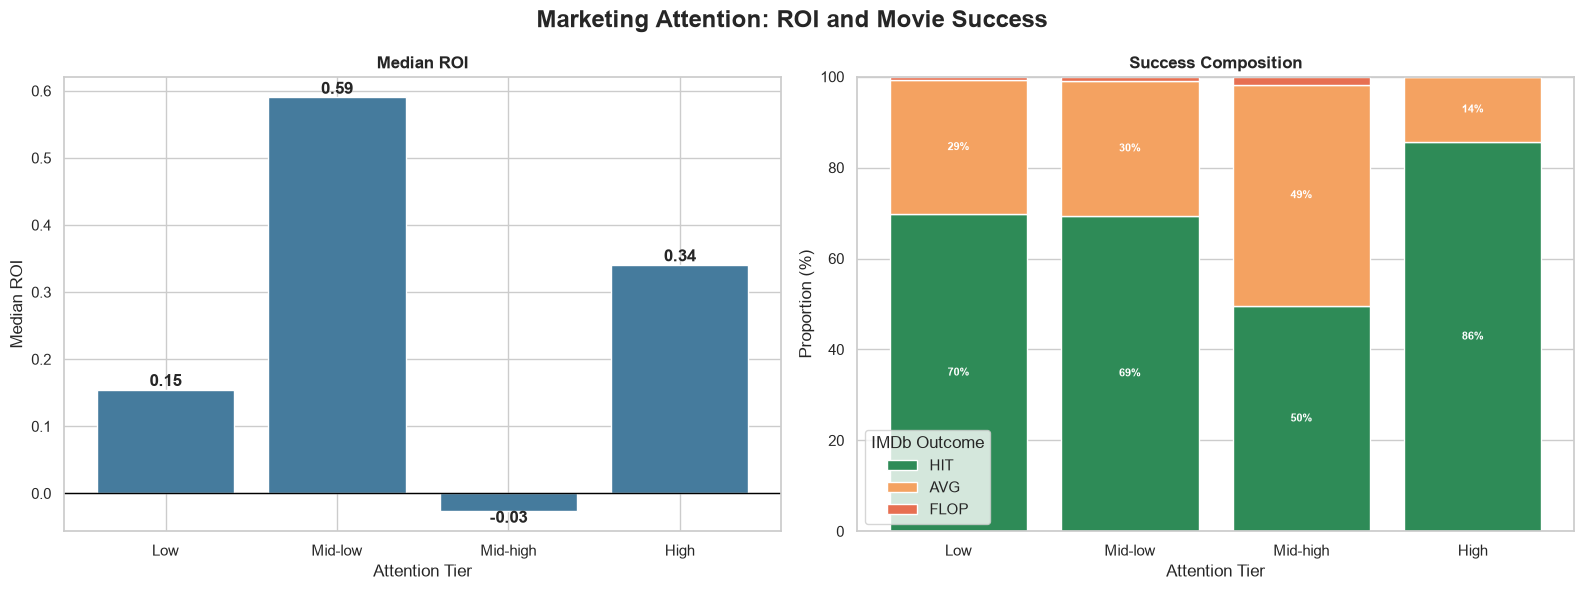

In [33]:
# ATTENTION — ROI + SUCCESS COMPOSITION

attention_combined = attention_summary.merge(attention_category, on="attention_tier")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROI
x = np.arange(len(attention_combined))

bars = axes[0].bar(x, attention_combined["median_roi"], color="#457B9D")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(attention_combined["attention_tier"])
axes[0].set_title("Median ROI", fontweight="bold")
axes[0].set_xlabel("Attention Tier")
axes[0].set_ylabel("Median ROI")
for bar, value in zip(bars, attention_combined["median_roi"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontweight="bold",
    )
# Success composition
bottom = np.zeros(len(attention_combined))

for category in SUCCESS_CATEGORIES:
    values = attention_combined[category].values
    axes[1].bar(
        x,
        values,
        bottom=bottom,
        color=SUCCESS_COLORS[category],
        label=category,
        edgecolor="white",
    )
    for i, value in enumerate(values):
        if value >= 5:
            axes[1].text(
                i,
                bottom[i] + value / 2,
                f"{value:.0f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
                fontweight="bold",
            )

    bottom += values

axes[1].set_xticks(x)
axes[1].set_xticklabels(attention_combined["attention_tier"])
axes[1].set_ylim(0, 100)
axes[1].set_title("Success Composition", fontweight="bold")
axes[1].set_xlabel("Attention Tier")
axes[1].set_ylabel("Proportion (%)")
axes[1].legend(title="IMDb Outcome")
fig.suptitle(
    "Marketing Attention: ROI and Movie Success", fontsize=17, fontweight="bold"
)

plt.tight_layout()
plt.show()



5. INDUSTRY TREND


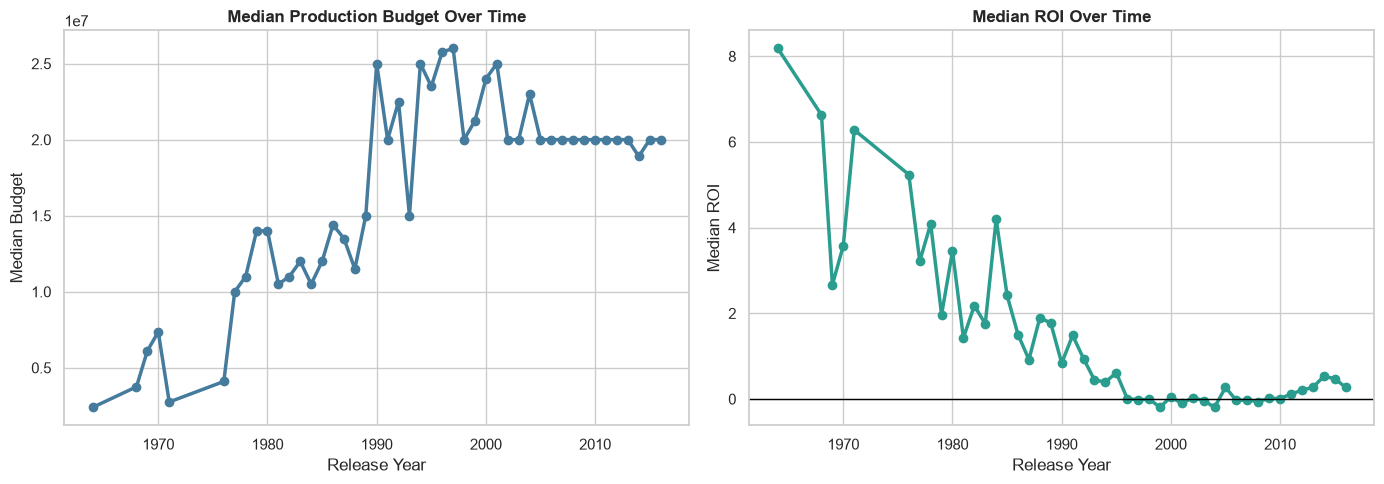

In [34]:
# INDUSTRY TREND

print_section("5. INDUSTRY TREND")
yearly = (
    df.groupby("title_year")
    .agg(
        movies=("gross", "size"),
        median_budget=("budget", "median"),
        median_roi=("roi", "median"),
    )
    .query("movies >= 10")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Budget trend
axes[0].plot(
    yearly["title_year"],
    yearly["median_budget"],
    color="#457B9D",
    linewidth=2.5,
    marker="o",
)

axes[0].set_title("Median Production Budget Over Time", fontweight="bold")
axes[0].set_xlabel("Release Year")
axes[0].set_ylabel("Median Budget")

# ROI trend
axes[1].plot(
    yearly["title_year"],
    yearly["median_roi"],
    color="#2A9D8F",
    linewidth=2.5,
    marker="o",
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Median ROI Over Time", fontweight="bold")
axes[1].set_xlabel("Release Year")
axes[1].set_ylabel("Median ROI")
plt.tight_layout()
plt.show()